In [20]:
import sklearn

from sklearn.datasets import make_circles

In [ ]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

len(X), len(y)

(1000, 1000)

: 

: 

In [ ]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

: 

: 

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})
circles.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


: 

: 

Text(0.5, 0, 'X0')

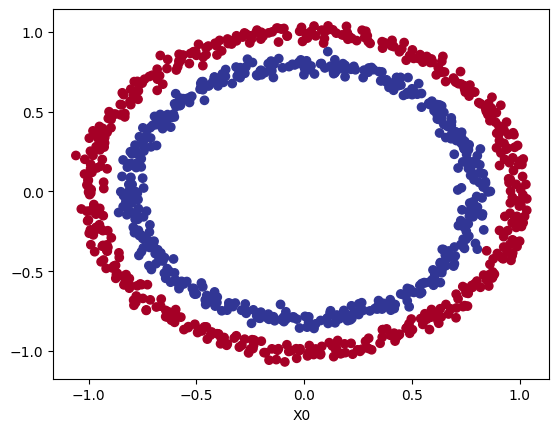

: 

: 

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("X0")

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

: 

: 

In [ ]:
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

: 

: 

In [ ]:
import torch
from torch import nn
torch.__version__

X_tensor = torch.from_numpy(X).type(torch.float) # convert to torch tensor and make sure it's the right datatype (float)
y_tensor = torch.from_numpy(y).type(torch.float) # convert to torch tensor and make sure it's the right datatype (float)

: 

: 

In [ ]:
X_tensor[:5], y_tensor[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

: 

: 

In [ ]:
#split data into training and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tensor, 
                                                    y_tensor, 
                                                    test_size=0.2, 
                                                    random_state=42) # 20% test size, 80% train size

: 

: 

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

: 

: 

In [ ]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=8) # input layer (2 features) to hidden layer (8 features)
        self.layer_2 = nn.Linear(in_features=8, out_features=1) # hidden layer (8 features) to output layer (1 feature)
    
    def forward(self, x):
        return self.layer_2(self.layer_1(x))
    
model_0 = CircleModelV0().to(device)
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.2408,  0.1768],
                      [ 0.6281, -0.5509],
                      [-0.3018, -0.5257],
                      [-0.2620,  0.4483],
                      [ 0.3707, -0.2859],
                      [-0.6822, -0.6126],
                      [-0.5779,  0.2456],
                      [-0.3348,  0.3910]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.4969,  0.5063,  0.5122, -0.2210, -0.6975,  0.4532,  0.2010,  0.0832],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2410, -0.0465, -0.2017,  0.1494,  0.0573, -0.0586, -0.2248,  0.2157]],
                     device='cuda:0')),
             ('layer_2.bias', tensor([-0.2813], device='cuda:0'))])

: 

: 

In [ ]:
loss_fn = nn.BCEWithLogitsLoss() # combine sigmoid activation function and binary cross entropy loss in one class

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = correct / len(y_pred)
    return acc


model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))
y_logits[:5]


tensor([[-0.5785],
        [-0.4556],
        [-0.8382],
        [-0.5052],
        [-0.7386]], device='cuda:0')

: 

: 

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs[:5]

tensor([[0.3593],
        [0.3880],
        [0.3019],
        [0.3763],
        [0.3233]], device='cuda:0')

: 

: 

In [ ]:
torch.round(y_pred_probs)[:5]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

: 

: 

In [ ]:
torch.manual_seed(42)
epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(X_train).squeeze() # forward pass
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels
    loss = loss_fn(y_logits, y_train) # calculate loss
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # calculate accuracy
    optimizer.zero_grad() # zero gradients
    loss.backward() # perform backpropagation
    optimizer.step() # update parameters
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}")

: 

: 

tensor([[0.0000],
        [0.1000],
        [0.2000],
        [0.3000],
        [0.4000]])
tensor([[ 0.0000,  0.1000,  0.2000,  0.3000,  0.4000,  0.5000,  0.6000,  0.7000,
          0.8000,  0.9000,  1.0000,  1.1000,  1.2000,  1.3000,  1.4000,  1.5000,
          1.6000,  1.7000,  1.8000,  1.9000,  2.0000,  2.1000,  2.2000,  2.3000,
          2.4000,  2.5000,  2.6000,  2.7000,  2.8000,  2.9000,  3.0000,  3.1000,
          3.2000,  3.3000,  3.4000,  3.5000,  3.6000,  3.7000,  3.8000,  3.9000,
          4.0000,  4.1000,  4.2000,  4.3000,  4.4000,  4.5000,  4.6000,  4.7000,
          4.8000,  4.9000,  5.0000,  5.1000,  5.2000,  5.3000,  5.4000,  5.5000,
          5.6000,  5.7000,  5.8000,  5.9000,  6.0000,  6.1000,  6.2000,  6.3000,
          6.4000,  6.5000,  6.6000,  6.7000,  6.8000,  6.9000,  7.0000,  7.1000,
          7.2000,  7.3000,  7.4000,  7.5000,  7.6000,  7.7000,  7.8000,  7.9000,
          8.0000,  8.1000,  8.2000,  8.3000,  8.4000,  8.5000,  8.6000,  8.7000,
          8.8000, 

: 

: 

In [ ]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=8) # input layer (2 features) to hidden layer (8 features)
        self.layer_2 = nn.Linear(in_features=8, out_features=8)
        self.layer_3 = nn.Linear(in_features=8, out_features=1) # hidden layer (8 features) to output layer (1 feature)
        self.relu = nn.ReLU() # add non-linearity to the model

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_2 = CircleModelV2().to(device)
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.2975, -0.4238],
                      [ 0.2213, -0.3640],
                      [-0.0563, -0.6747],
                      [-0.2698, -0.2943],
                      [-0.3092,  0.4413],
                      [ 0.6967,  0.5413],
                      [ 0.0101,  0.4783],
                      [-0.4233, -0.5861]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.4291, -0.2028, -0.3517, -0.5962,  0.1613, -0.0684,  0.4906,  0.6786],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2656,  0.3515,  0.1079,  0.1706, -0.0839, -0.0029,  0.3382,  0.1087],
                      [ 0.0334, -0.1057, -0.3000,  0.2263,  0.2720,  0.1268,  0.1610,  0.2764],
                      [ 0.1339,  0.2389,  0.0094,  0.2801, -0.1589,  0.2805, -0.3304, -0.3295],
                      [ 0.2845,  0.0167, -0.2227,  0.0588,  0.1654, -0.0609, -0.3373, -0.1089],
                      [ 0.1914,

: 

: 

In [29]:
#train the model
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


epochs = 1000

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = correct / len(y_pred)
    return acc


for epoch in range(epochs):
    model_2.train()
    y_logits = model_2(X_train).squeeze() # forward pass
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels
    loss = loss_fn(y_logits, y_train) # calculate loss
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred) # calculate accuracy
    optimizer.zero_grad() # zero gradients
    loss.backward() # perform backpropagation
    optimizer.step() # update parameters

    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}")




Epoch: 0 | Loss: 0.69102 | Accuracy: 0.55
Epoch: 10 | Loss: 0.69089 | Accuracy: 0.56
Epoch: 20 | Loss: 0.69076 | Accuracy: 0.56
Epoch: 30 | Loss: 0.69062 | Accuracy: 0.57
Epoch: 40 | Loss: 0.69047 | Accuracy: 0.57
Epoch: 50 | Loss: 0.69032 | Accuracy: 0.57
Epoch: 60 | Loss: 0.69015 | Accuracy: 0.58
Epoch: 70 | Loss: 0.68998 | Accuracy: 0.58
Epoch: 80 | Loss: 0.68980 | Accuracy: 0.58
Epoch: 90 | Loss: 0.68961 | Accuracy: 0.59
Epoch: 100 | Loss: 0.68941 | Accuracy: 0.59
Epoch: 110 | Loss: 0.68920 | Accuracy: 0.59
Epoch: 120 | Loss: 0.68899 | Accuracy: 0.59
Epoch: 130 | Loss: 0.68877 | Accuracy: 0.60
Epoch: 140 | Loss: 0.68854 | Accuracy: 0.60
Epoch: 150 | Loss: 0.68829 | Accuracy: 0.59
Epoch: 160 | Loss: 0.68804 | Accuracy: 0.59
Epoch: 170 | Loss: 0.68777 | Accuracy: 0.59
Epoch: 180 | Loss: 0.68749 | Accuracy: 0.59
Epoch: 190 | Loss: 0.68720 | Accuracy: 0.59
Epoch: 200 | Loss: 0.68689 | Accuracy: 0.59
Epoch: 210 | Loss: 0.68657 | Accuracy: 0.60
Epoch: 220 | Loss: 0.68624 | Accuracy: 0.60

In [30]:
model_2.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_2(X_test).squeeze()))
y_preds[:10], y_test[:10]


(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

c:\Users\Theo\source\repos\.venvs\neural_networks_cuda\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


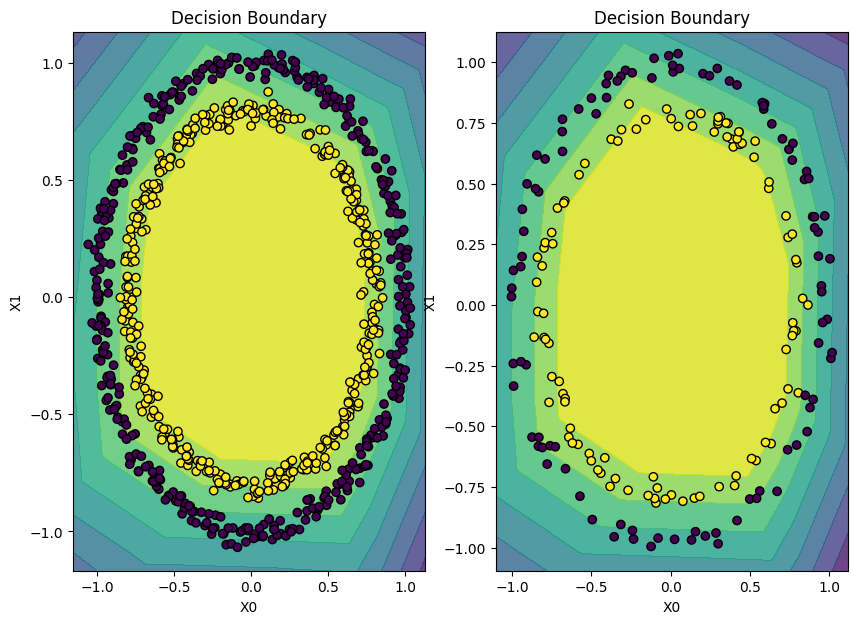

In [32]:
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, 0.01), torch.arange(y_min, y_max, 0.01))
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1).to(device)
    with torch.inference_mode():
        pred_func = model(grid).reshape(xx.shape)
    plt.contourf(xx.cpu(), yy.cpu(), pred_func.cpu(), alpha=0.8)
    plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), edgecolors='k', marker='o')
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.title('Decision Boundary')

plt.figure(figsize=(10, 7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)
